# N-variable, M-output L.R. (Keras)

## Load modules

이 코드는 나이와 BMI 두 개의 입력값을 넣으면 혈압의 HIGH 값과 LOW 값을 동시에 예측하는 선형회귀 모델입니다.
즉, 입력은 2개입니다.
나이, BMI
출력도 2개입니다.
수축기 혈압 HIGH, 이완기 혈압 LOW
그래서 제목의 의미는 다음과 같습니다.
N-variable은 입력 변수가 여러 개라는 뜻입니다. 여기서는 AGE, BMI 두 개입니다.
M-output은 출력값이 여러 개라는 뜻입니다. 여기서는 HIGH 혈압, LOW 혈압 두 개입니다.
L.R.은 Linear Regression, 즉 선형회귀입니다.
Keras는 TensorFlow 안에서 모델을 쉽고 간단하게 만들 수 있게 해주는 고수준 딥러닝 도구입니다.
이전 코드와 다르게 Keras를 사용하는 이유
이전 방식에서는 보통 W, B를 직접 만들고, 예측식 H = XW + B를 직접 작성하고, 손실함수 cost를 직접 계산하고, GradientTape로 미분해서 W와 B를 직접 업데이트했습니다.
그 방식은 원리를 이해하기에는 좋습니다. 하지만 코드가 길고, 실수하기 쉽고, 입력과 출력이 많아질수록 복잡해집니다.
이번 코드는 Keras를 사용합니다. Keras를 쓰면 모델 구조, 손실함수, 최적화 방법, 학습 반복을 간단하게 처리할 수 있습니다.
예를 들어 이전에는 다음 과정을 직접 작성해야 했습니다.

가중치 W 만들기
편향 B 만들기
예측값 계산하기
손실함수 계산하기
미분하기
W, B 업데이트하기
반복 학습하기
하지만 Keras에서는 이 과정을 다음 세 줄로 크게 줄일 수 있습니다.
model = Sequential(...)
model.compile(...)
model.fit(...)
즉, Keras는 딥러닝 모델을 더 쉽게 만들고, 더 쉽게 학습시키기 위해 사용합니다. 특히 나중에 선형회귀가 아니라 신경망, CNN, RNN, 다층 퍼셉트론으로 확장할 때 Keras 방식이 훨씬 편리합니다.

In [2]:
# ================================
# 1. 라이브러리 불러오기
# ================================

import numpy as np                 # 수치 계산을 위한 라이브러리
import tensorflow as tf            # 머신러닝/딥러닝 라이브러리
import matplotlib.pyplot as plt    # 그래프 그리기용 라이브러리

# 현재 사용 중인 라이브러리 버전 확인 (환경 문제 확인용)
print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.16.2
Matplotlib Version :3.10.0


## Input and Label

In [4]:
# ================================
# 2. 입력 데이터 (X) 생성
# ================================

# 각 데이터는 [나이, BMI] 구조
# 즉 입력 변수 2개 (N-variable)
x_input = tf.constant([
    [25,22],[25,26],[25,30],
    [35,22],[35,26],[35,30],
    [45,22],[45,26],[45,30],
    [55,22],[55,26],[55,30],
    [65,22],[65,26],[65,30],
    [73,22],[73,26],[73,30]
], dtype=tf.float32)

# ================================
# 3. 정답 데이터 (Y) 생성
# ================================

# 각 데이터는 [HIGH 혈압, LOW 혈압]
# 즉 출력 변수 2개 (M-output)
labels = tf.constant([
    [118,72],[125,80],[130,80],
    [120,74],[130,82],[135,85],
    [128,78],[135,84],[140,88],
    [135,82],[140,88],[145,90],
    [140,85],[145,90],[150,95],
    [145,88],[150,92],[155,98]
], dtype=tf.float32)

## Min Max Scaler

In [5]:
# ================================
# 4. Min-Max 정규화 (중요)
# ================================

# 원래 데이터를 따로 저장 (출력할 때 사용)
x_input_org = x_input

# 각 열(AGE, BMI)의 최소값과 최대값 계산
x_min = np.min(x_input, axis=0)
x_max = np.max(x_input, axis=0)

# 정규화 수행 (0 ~ 1 사이 값으로 변환)
# 이유: 값 크기가 다르면 학습이 잘 안됨
x_input = (x_input - x_min) / (x_max - x_min)

## Model 정의

In [6]:
# ================================
# 5. Keras 모델 정의
# ================================

# Sequential 모델: 층을 순서대로 쌓는 구조
model = tf.keras.models.Sequential([
    
    # 입력층: 입력 데이터가 2개라는 의미 (AGE, BMI)
    tf.keras.Input(shape=(2,)),
    
    # Dense 층: 완전 연결층
    # 출력이 2개 → HIGH BP, LOW BP
    tf.keras.layers.Dense(2)
])

# 모델 구조 확인
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (24.00 B)

 Trainable params: 6 (24.00 B)

 Non-trainable params: 0 (0.00 B)

## 모델 구조 설명 (Keras summary 해석)
이 모델은 매우 단순한 구조의 선형회귀 모델이다.  입력값 2개를 받아서 출력값 2개를 만드는 구조이다.

### 1. Model: "sequential"
Sequential 모델은 층을 순서대로 쌓는 가장 기본적인 구조이다.  입력 → 계산 → 출력 흐름이 한 방향으로만 진행된다.

### 2. Layer (dense)
Dense는 완전 연결층이다.  입력된 모든 값이 출력과 연결된다.

출력 Shape의 의미는 다음과 같다.
- None → 데이터 개수 (몇 개가 들어올지 아직 모름)
- 2 → 출력값이 2개

즉, 이 모델은 한 번에 혈압 2개 값을 예측한다.
HIGH 혈압  
LOW 혈압  

### 3. Param # (파라미터 개수 = 6)
이 모델에서 학습해야 할 값은 총 6개이다.
구성은 다음과 같다.
- 입력 2개 → 출력 2개 연결 → 가중치 4개
- 출력마다 bias 1개씩 → bias 2개

정리하면
가중치 4개 + bias 2개 = 총 6개

### 4. Total params: 6
모델이 학습해야 할 전체 변수 개수이다.  이 값이 작을수록 모델은 단순한 구조이다.

### 5. Trainable params: 6
학습하면서 실제로 업데이트되는 값이다.  여기서는 모든 파라미터가 학습 대상이다.

### 6. Non-trainable params: 0
학습되지 않는 고정된 값이다.  이 모델에서는 모두 학습 대상이기 때문에 0이다.

### 핵심 정리
이 모델은 입력 2개(나이, BMI)를 받아  출력 2개(혈압 HIGH, LOW)를 예측하는

가중치 4개 + bias 2개로 구성된  매우 단순한 선형회귀 모델이다.

## Model compile

In [7]:
# ================================
# 6. 모델 컴파일
# ================================

model.compile(
    # SGD: 가장 기본적인 경사하강법
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    
    # MSE: 예측값과 실제값의 차이를 제곱하여 평균
    loss='mean_squared_error'
)

## 학습 (Training)

In [8]:
# ================================
# 7. 모델 학습
# ================================

# history에 학습 과정 저장 (그래프 그리기 위해 필요)
history = model.fit(x_input, labels, epochs=1000)

Epoch 1/1000


2026-05-02 22:30:59.831258: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 13010.3887
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9307.1201
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 6671.6245
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 4795.7402
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 3460.2473
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2509.1975
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 1831.6538
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1348.6974
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1004.1868
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 758.1843
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 582.2789
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 456.2591
Epoch 13/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 365.7464
Epoch 14/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 300.5117
Epoch 15/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/s

In [9]:
history.history['loss'][1]

9307.1201171875

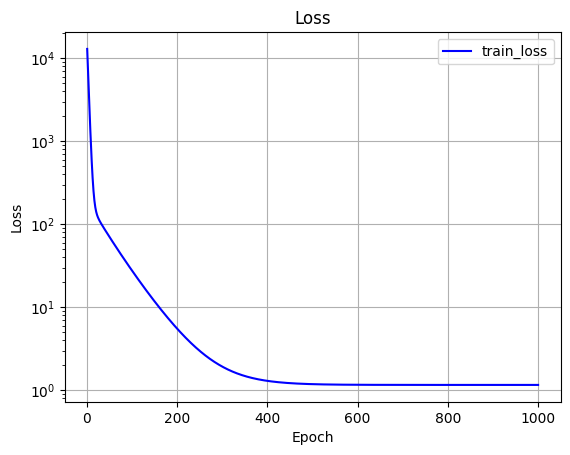

In [10]:
# ================================
# 8. Loss 그래프 시각화
# ================================

# loss 값 가져오기
loss = history.history['loss']

# epoch 번호 생성
epochs = range(1, len(loss)+1)

# 그래프 그리기
plt.title('Loss')
plt.plot(epochs, loss, 'b', label='train_loss')
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')

# 로그 스케일로 변환 (변화가 더 잘 보임)
plt.semilogy()

plt.show()

In [11]:
# ================================
# 9. 학습 결과 확인
# ================================

# 학습된 모델로 예측 수행
H_x = model.predict(x_input)

# 원래 값과 비교 출력
for x, h, l in zip(x_input_org, H_x, labels):
    print("Age:{}, BMI:{} => 예측 BP:{:>7.4},{:>7.4} | 실제 BP:{}".format(
        x[0], x[1], h[0], h[1], l
    ))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Age:25.0, BMI:22.0 => 예측 BP:  117.9,   72.4 | 실제 BP:[118.  72.]
Age:25.0, BMI:26.0 => 예측 BP:  123.7,  77.15 | 실제 BP:[125.  80.]
Age:25.0, BMI:30.0 => 예측 BP:  129.4,   81.9 | 실제 BP:[130.  80.]
Age:35.0, BMI:22.0 => 예측 BP:  123.3,   75.6 | 실제 BP:[120.  74.]
Age:35.0, BMI:26.0 => 예측 BP:  129.1,  80.35 | 실제 BP:[130.  82.]
Age:35.0, BMI:30.0 => 예측 BP:  134.8,  85.11 | 실제 BP:[135.  85.]
Age:45.0, BMI:22.0 => 예측 BP:  128.7,  78.81 | 실제 BP:[128.  78.]
Age:45.0, BMI:26.0 => 예측 BP:  134.5,  83.56 | 실제 BP:[135.  84.]
Age:45.0, BMI:30.0 => 예측 BP:  140.2,  88.31 | 실제 BP:[140.  88.]
Age:55.0, BMI:22.0 => 예측 BP:  134.1,  82.01 | 실제 BP:[135.  82.]
Age:55.0, BMI:26.0 => 예측 BP:  139.9,  86.76 | 실제 BP:[140.  88.]
Age:55.0, BMI:30.0 => 예측 BP:  145.6,  91.52 | 실제 BP:[145.  90.]
Age:65.0, BMI:22.0 => 예측 BP:  139.5,  85.22 | 실제 BP:[140.  85.]
Age:65.0, BMI:26.0 => 예측 BP:  145.3,  89.97 | 실제 BP:[145.  90.]
Age:65.0, BMI:30.0 => 예측 BP:  151.0,  94.72 | 실제 BP:[150.  95.]
Ag

## 결과 해석

본 출력 결과는 모델이 학습 데이터에 대해 얼마나 정확하게 예측하고 있는지를 보여주는 부분이다. 각 행은 입력값(나이, BMI), 모델 예측값(혈압), 실제값을 비교한 결과이다.

### 전체 평가

모델은 대부분의 데이터에서 실제 혈압과 매우 유사한 값을 예측하고 있다.  HIGH 혈압과 LOW 혈압 모두에서 오차는 대부분 ±1 이내로 나타난다.  
이는 모델이 데이터의 패턴을 매우 정확하게 학습했음을 의미한다.

### 개별 결과 해석 예시

- Age:25, BMI:22  
  예측: 117.9 / 72.4  
  실제: 118 / 72  
  → 거의 동일한 수준으로 매우 정확한 예측이다.

- Age:45, BMI:30  
  예측: 140.2 / 88.31  
  실제: 140 / 88  
  → 오차가 매우 작고 안정적인 예측이다.

- Age:65, BMI:30  
  예측: 151.0 / 94.72  
  실제: 150 / 95  
  → 약간의 오차는 있지만 전체 흐름은 정확하다.

### 패턴 학습 여부

모든 결과를 보면 다음 특징이 나타난다.

- 나이가 증가할수록 혈압이 증가한다.
- BMI가 증가할수록 혈압이 증가한다.
- 모델 예측값도 동일한 방향으로 증가한다.

즉, 모델은 단순 암기가 아니라  
나이와 BMI가 혈압에 미치는 **선형 관계**를 제대로 학습한 상태이다.

### 왜 이렇게 정확한가

이 데이터는 선형 구조를 가지고 있다.

혈압 ≈ (나이 × 계수) + (BMI × 계수) + bias
따라서 Dense(선형층) 하나만으로도 충분히 정확하게 표현이 가능하다.

### 오차가 존재하는 이유

예측값이 실제값과 완전히 같지 않은 이유는 다음과 같다.
- 학습 반복 횟수 제한
- 학습률 영향
- 부동소수점 계산 오차

따라서 아주 미세한 차이가 발생한다.

### 최종 결론

이 모델은 나이와 BMI에 따른 혈압 변화를 매우 정확하게 학습했으며, 선형 데이터에 대해 선형 모델이 얼마나 효과적인지를 보여주는 좋은 사례이다.

## Predict

In [12]:
# ================================
# 10. 새로운 데이터 예측 함수
# ================================

def predict(x):
    # 반드시 같은 방식으로 정규화 해야 함
    return model.predict((x - x_min) / (x_max - x_min))


In [13]:

# ================================
# 11. 새로운 입력 테스트
# ================================

# 나이 50, BMI 25인 사람
x_test = tf.constant([[50.0, 25.0]], dtype=tf.float32)

# 예측 수행
H_x = predict(x_test)

# 결과 출력
print("Age : {}, BMI : {} => 예측 BP : {:>7.4}, {:>7.4}".format(
    x_test[0,0], x_test[0,1], H_x[0,0], H_x[0,1]
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
Age : 50.0, BMI : 25.0 => 예측 BP :   135.7,   83.97


# ================================
# 핵심 개념 요약 (코드 관점)
# ================================

# 1. 입력 2개 → AGE, BMI
# 2. 출력 2개 → HIGH BP, LOW BP
# 3. Dense(2) = 선형회귀를 Keras로 표현한 것
# 4. compile = 학습 방법 설정
# 5. fit = 학습 실행
# 6. predict = 결과 예측
# 7. 정규화는 반드시 필요
